# 机械臂动力学参数辨识

In [1]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pinocchio as pin
import cvxpy as cp
from scipy.signal import butter, filtfilt
from pinocchio.robot_wrapper import RobotWrapper
from dataclasses import dataclass

In [2]:
urdf_path = "URe/urdf/ur10e.urdf"
model, collision_model, visual_model = pin.buildModelsFromUrdf(urdf_path, verbose=True)
robot = RobotWrapper(model, collision_model, visual_model)

# 初始化随机生成器
np_rng = np.random.default_rng(0)

In [3]:
robot.model.inertias[0].toDynamicParameters()

array([4.        , 0.        , 0.        , 0.        , 0.00610633,
       0.        , 0.00610633, 0.        , 0.        , 0.01125   ])

## 傅里叶激励轨迹设计
1. 傅里叶级数


In [1]:
# 生成随机傅里叶激励轨迹，并计算速度和加速度，用于机械臂动力学参数辨识
class FourierSeriesTraj:
    def __init__(self, x0, A, B, w):
        """
        x(t) = x0 + sum_{k=1..N} [A_k/(w*k) * sin(w*k*t) - B_k/(w*k) * cos(w*k*t)]

        A - sine coefficients, shape: (dof, N)
        B - cosine coefficients, shape: (dof, N)
        w - fundamental frequency
        """
        self.x0 = np.asarray(x0, dtype=float)
        self.A = np.asarray(A, dtype=float)
        self.B = np.asarray(B, dtype=float)
        self.w = float(w)

        if self.A.shape != self.B.shape:
            raise ValueError("A and B must have the same shape")
        if self.A.ndim != 2:
            raise ValueError("A and B must be 2-D arrays with shape (dof, N)")
        if self.x0.shape[0] != self.A.shape[0]:
            raise ValueError("x0 dimension must match A/B first axis")
        if self.w <= 0.0:
            raise ValueError("w must be positive")

        self.dof, self.N = self.A.shape
        self.harmonics = np.arange(1, self.N + 1, dtype=float)

    def _t_array(self, t):
        t = np.asarray(t, dtype=float)
        if t.ndim == 0:
            t = t[None]
        return t

    def __call__(self, t):
        t = self._t_array(t)
        wt = self.w * np.outer(self.harmonics, t)  # (N, T)
        scale = 1.0 / (self.w * self.harmonics)     # (N,)

        pos = self.x0[:, None] + (self.A * scale[None, :]) @ np.sin(wt) - (self.B * scale[None, :]) @ np.cos(wt)
        return pos[:, 0] if pos.shape[1] == 1 else pos

    def velocity(self, t):
        t = self._t_array(t)
        wt = self.w * np.outer(self.harmonics, t)

        vel = self.A @ np.cos(wt) + self.B @ np.sin(wt)
        return vel[:, 0] if vel.shape[1] == 1 else vel

    def acceleration(self, t):
        t = self._t_array(t)
        wt = self.w * np.outer(self.harmonics, t)
        wk = self.w * self.harmonics

        acc = -(self.A * wk[None, :]) @ np.sin(wt) + (self.B * wk[None, :]) @ np.cos(wt)
        return acc[:, 0] if acc.shape[1] == 1 else acc

    # 向后兼容原始拼写
    def accleration(self, t):
        return self.acceleration(t)


def generate_random_fourier_excitation(
    q0,
    num_harmonics=8,
    w=2.0 * np.pi / 10.0,
    amplitude=0.3,
    rng=None,
):
    """
    生成随机傅里叶激励轨迹
    返回: FourierSeriesTraj
    """
    q0 = np.asarray(q0, dtype=float)
    dof = q0.shape[0]

    if rng is None:
        rng = np.random.default_rng()

    A = rng.uniform(-amplitude, amplitude, size=(dof, num_harmonics))
    B = rng.uniform(-amplitude, amplitude, size=(dof, num_harmonics))
    return FourierSeriesTraj(x0=q0, A=A, B=B, w=w)


# 示例:
# traj_fs = generate_random_fourier_excitation(robot.q0, num_harmonics=12, rng=np_rng)
# t = np.linspace(0.0, 30.0, 3000)
# q = traj_fs(t).T
# qd = traj_fs.velocity(t).T
# qdd = traj_fs.acceleration(t).T



## 动力学参数线性化

### 1. 电机动力学简化模型：
关节的总惯性扭矩为：$\tau=(I_{load} + I_{reflected}) \cdot \ddot{\theta}$
- 反射转动惯量：$$I_{reflected}=I_m \cdot N^2$$ 其中，$I_m$表示电机转动惯量；$N$表示减速器减速比

### 2. 摩擦力模型  

#### 2.1 库仑摩擦  
最简单的摩擦力模型，仅考虑运动方向对摩擦力的影响：  
$$F_f = F_c \cdot \text{sign}(v) $$
- $F_c$：库仑摩擦系数（恒定值，与速度无关）；  
- $v$：相对运动速度；  
- $\text{sign}(v)$：符号函数，用于表示摩擦力与运动方向相反。  

**特点**：适用于低速、干摩擦主导的场景，模型简单但忽略了速度对摩擦力的影响。  


#### 2.2 粘性摩擦模型  
摩擦力大小与速度成正比，方向与运动方向相反：  
$$ F_f = F_v \cdot v $$
- $F_v$：粘性摩擦系数（与速度相关的比例系数）。  

**特点**：适用于润滑良好、流体阻尼主导的场景（如液压系统、高速旋转部件），但无法描述低速时的静摩擦特性。  


#### 2.3 组合摩擦模型（三参数模型）  
融合干摩擦与粘性摩擦的特性，并引入常数项补偿静摩擦或模型误差，是工程中最常用的模型之一：  
$$ F_f = F_v \cdot v + F_c \cdot \text{sign}(v) + F_0 $$

- **参数含义**：  
  - $F_v$：粘性摩擦系数（与速度成正比）；  
  - $F_c$：库仑摩擦系数（与方向相关的恒定值）；  
  - $F_0$：常数项（补偿静摩擦或系统偏移）；  
  - $v$：相对运动速度；  
  - $\text{sign}(v)$：符号函数（定义同库仑摩擦模型）。  

**特点**：兼顾低速（库仑摩擦、静摩擦）和高速（粘性摩擦）特性，精度较高且形式简单，广泛应用于机器人关节建模。  


#### 2.4 非线性摩擦模型（Stribeck模型）  
考虑低速时摩擦力随速度的非线性变化（Stribeck效应），更贴近实际物理过程：  
$$ F_f = F_c \cdot \text{sign}(v) + (F_s - F_c) \cdot e^{-(v/v_s)^2} + F_v \cdot v $$
- $F_s$：静摩擦系数（启动时的最大摩擦力）；  
- $v_s$：Stribeck特征速度（非线性变化的临界速度）。  

**特点**：精度更高，但参数辨识复杂，适用于对建模精度要求极高的场景（如精密定位系统）。  


#### 2.5 三参数线性摩擦模型（重点解析）  
工程中最常用的**三参数模型**（如机器人关节摩擦力建模），表达式为：  
$$ F_f = F_v \cdot v + F_c \cdot \text{sign}(v) + F_0 $$

各参数物理意义：

| 参数       | 物理意义                                                                 | 单位示例          |  
|------------|--------------------------------------------------------------------------|-------------------|  
| $F_v$      | 粘性摩擦系数，反映摩擦力随速度增加的幅度（如润滑油阻尼）                 | N·s/m 或 N·s/rad  |  
| $F_c$      | 库仑摩擦系数，反映接触面滑动摩擦的恒定阻力（如齿轮啮合摩擦）             | N 或 N·m          |  
| $F_0$      | 常数项，可表示静摩擦（启动阻力）或模型简化带来的误差补偿                 | N 或 N·m          |  

符号函数定义：
$$ \text{sign}(v) = \begin{cases} 
1 & \text{若 } v > 0 \text{（正向运动）} \\
-1 & \text{若 } v < 0 \text{（反向运动）} \\
0 & \text{若 } v = 0 \text{（静止）}
\end{cases} $$  

模型优势：
- **平衡精度与复杂度**：比干摩擦/粘性摩擦模型更全面，比Stribeck模型更简单，适合工程应用；  
- **线性可辨识性**：可转化为线性回归形式，便于通过实验数据估计参数（见下文“参数辨识”）。  


#### 2.6 参数辨识方法  
三参数模型的参数（$F_v, F_c, F_0$）需通过实验数据辨识，核心是将模型转化为**线性回归形式**。  

**线性回归转化：**
令参数向量 $\theta = [F_v, F_c, F_0]^T$，特征向量 $\phi(v) = [v, \text{sign}(v), 1]^T$，则模型可写为：  
$$ F_f = \phi(v) \cdot \theta $$

**回归矩阵构造：** 
对于多关节系统（如机器人），需为每个关节构造回归矩阵 $\Phi$。例如，2个关节的回归矩阵结构为：  

| 关节 | 列1（$F_v$系数） | 列2（$F_c$系数） | 列3（$F_0$系数） | 列4（$F_v'$系数） | 列5（$F_c'$系数） | 列6（$F_0'$系数） |  
|------|------------------|------------------|------------------|-------------------|-------------------|-------------------|  
| 1    | $v_1$            | $\text{sign}(v_1)$ | $1$              | $0$               | $0$               | $0$               |  
| 2    | $0$              | $0$              | $0$              | $v_2$             | $\text{sign}(v_2)$ | $1$               |  

**求解参数：**  
通过采集速度 $v$ 和对应的摩擦力 $F_f$ 数据，利用最小二乘法求解：  
$$ \hat{\theta} = (\Phi^T \Phi)^{-1} \Phi^T F_f $$

#### 2.7 总结  
摩擦力模型是机械系统建模的核心环节，其中**三参数线性模型**因兼顾精度与实用性，成为工程中最常用的选择。通过实验辨识参数后，该模型可有效补偿摩擦力对系统的影响，为高精度控制提供支持。  

若需更高精度（如低速非线性场景），可扩展至Stribeck模型，但需权衡参数辨识的复杂度。  

In [5]:
# 获取机器人动力学的回归矩阵，它建立了关节扭矩和动力学参数之间的映射关系
def get_dynamics_parameters(
        robot: RobotWrapper, 
        include_motor_dynamics: bool = False,
        include_friction_model: bool = False,
        ):
    pi_theta = [robot.model.inertias[i].toDynamicParameters() for i in range(1, robot.nq + 1)]

    if include_motor_dynamics:
        zeros = np.zeros((robot.nq,))
        pi_theta = sum([[pi_theta[i], zeros[i:i+1]] for i in range(robot.nq)], [])

    if include_friction_model:
        pi_theta += [np.array([0., 0., 0.] * robot.nq)]

    pi_theta = np.concatenate(pi_theta, axis=0)
    return pi_theta.reshape(-1, 1)

def friction_regressor(
        robot: RobotWrapper, 
        qd: np.ndarray):
    """
    Computes friction model in the regressor.
    """
    # 库伦摩擦+粘性摩擦+静摩擦偏置
    Y_friction = np.zeros((robot.nq, robot.nq * 3))
    for i in range(robot.nq):
        Y_friction[i, i*3:(i+1)*3] = np.array([qd[i], np.sign(qd[i]), 1.])
    return Y_friction

def dyanmics_regressor(
        robot: RobotWrapper, 
        q: np.ndarray, 
        qd: np.ndarray, 
        qdd: np.ndarray, 
        include_motor_dynamics: bool = False):
    """
    Computes the joint torque regressor for the robot given joint positions, velocities, and accelerations.
    
    Parameters:
    - robot: RobotWrapper instance containing the robot model.
    - q: Joint positions (numpy array).
    - qd: Joint velocities (numpy array).
    - qdd: Joint accelerations (numpy array).
    - include_motor_dynamics: Boolean indicating whether to include motor dynamics in the regressor.
    
    Returns:
    - Y: The joint torque regressor matrix.
    """
    Y = pin.computeJointTorqueRegressor(robot.model, robot.data, q, qd, qdd)

    if include_motor_dynamics:
        Y_motor = np.diag(qdd)
        Y = np.concatenate(sum([[Y[:, i*10:(i+1)*10], Y_motor[:, i:i+1]] for i in range(robot.nq)], []), axis=1)
    return Y

pi_theta = get_dynamics_parameters(robot, include_motor_dynamics=True)

q = robot.q0
qd = pin.randomConfiguration(robot.model, -robot.model.velocityLimit, robot.model.velocityLimit)
qdd = qd
Y = dyanmics_regressor(robot, q, qd, qdd, include_motor_dynamics=True)

# 验证
tau = pin.rnea(robot.model, robot.data, q, qd, qdd).reshape(-1, 1)
# note: numpy>2.0版本数组广播策略做了变更, (3, 4) @ (4,) 等价于 ((3, 4) @ (4, 1)).squeeze(1)
# numpy<2.0的版本 (3, 4) @ (4,) 等价于 (3, 4) @ (4, 4), (4,)的矩阵按行广播
linearized_tau = Y @ pi_theta
print("估计误差:", np.linalg.norm(tau - linearized_tau))
assert np.allclose(tau, linearized_tau)

print("回归矩阵:", Y.shape)
print("动力学参数", pi_theta.shape, pi_theta)

估计误差: 1.4210861491463966e-14
回归矩阵: (6, 66)
动力学参数 (66, 1) [[ 7.77800000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 3.14743126e-02]
 [ 0.00000000e+00]
 [ 3.14743126e-02]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 2.18756250e-02]
 [ 0.00000000e+00]
 [ 1.29300000e+01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 3.96304500e+00]
 [ 1.63774703e+00]
 [ 0.00000000e+00]
 [ 1.63774703e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 3.63656250e-02]
 [ 0.00000000e+00]
 [ 3.87000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 1.10488500e+00]
 [ 4.26035033e-01]
 [ 0.00000000e+00]
 [ 4.26035033e-01]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 1.08843750e-02]
 [ 0.00000000e+00]
 [ 1.96000000e+00]
 [ 0.00000000e+00]
 [ 2.64600000e-01]
 [ 0.00000000e+00]
 [ 4.08292480e-02]
 [ 0.00000000e+00]
 [ 5.10824796e-03]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 4.12335000e-02]
 [ 0.00000000e+00]
 [ 1.96000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 2.35200000e-01]
 [ 3.33322480e-02]
 [ 0.0000000

## 1.1 计算最小动力学参数集

In [6]:
@dataclass
class QRResult:
    num_base_params: int = None
    num_dep_params: int = None
    permutation_matrix: np.ndarray = None
    beta: np.ndarray = None

In [7]:
N = 50

q_min = robot.model.lowerPositionLimit
q_max = robot.model.upperPositionLimit
qd_max = robot.model.velocityLimit
qdd_max = robot.model.velocityLimit * 2.

# 构建超定矩阵
W, tau_samples = [], []
for i in range(N):
    q = (q_max - q_min) * np_rng.random((6,)) + q_min
    qd = (2. * qd_max) * np_rng.random((6,)) - qd_max
    qdd = (2. * qdd_max) * np_rng.random((6,)) - qdd_max

    Y = dyanmics_regressor(robot, q, qd, qdd, include_motor_dynamics=True)
    W.append(Y)

    tau = pin.rnea(robot.model, robot.data, q, qd, qdd).reshape(-1, 1)
    tau_samples.append(tau)
    
W = np.concatenate(W, axis=0)
print("动力学回归超定矩阵:", W.shape)
tau_samples = np.concatenate(tau_samples, axis=0)

# QR分解: W @ E = Q @ R
Q, R, P = scipy.linalg.qr(W, pivoting=True)
E = np.eye(P.shape[0])[:, P]

print("W矩阵的秩:", np.linalg.matrix_rank(W))
print("QR分解结果:", Q.shape, R.shape, E.shape)
print("R矩阵的特征值:", np.diag(R))

动力学回归超定矩阵: (300, 66)
W矩阵的秩: 40
QR分解结果: (300, 300) (300, 66) (66, 66)
R矩阵的特征值: [-4.10032296e+02  3.91955204e+02  3.71700131e+02 -3.32221108e+02
 -3.07954647e+02  2.94808031e+02 -2.43893814e+02 -2.34510109e+02
  2.34451802e+02 -2.10878143e+02  2.09984022e+02 -2.03831601e+02
  2.01142785e+02 -1.81346114e+02  1.74676346e+02 -1.70755801e+02
 -1.25770886e+02 -1.03797735e+02  9.89497685e+01 -8.27517793e+01
 -7.95753492e+01 -6.95226884e+01 -6.30581293e+01 -5.99031295e+01
 -5.06200418e+01  4.83539010e+01 -4.74516258e+01 -4.51303655e+01
  4.48175178e+01 -3.99409061e+01  3.74289198e+01 -3.67221826e+01
  3.59784758e+01  3.27661226e+01 -2.99125695e+01  2.90394982e+01
 -2.18879129e+01  2.18442485e+01 -1.86698838e+01  1.42862667e+01
  1.04556960e-13  6.70425456e-14 -6.05041832e-14  5.38057760e-14
 -3.06183010e-14  2.37853488e-14 -2.26499114e-14  2.10263999e-14
  1.95006379e-14 -1.53590284e-14  1.16140507e-14 -1.09778773e-14
  9.56114924e-15  6.70798285e-15 -4.41508679e-15  4.41786349e-16
 -3.76794177

In [8]:
rank = np.linalg.matrix_rank(W)

R1 = R[:rank, :rank]  # 线性无关的列
R2 = R[:rank, rank:]  # 线性相关的列
# R1 @ beta = R2
beta = np.linalg.solve(R1, R2)
print("beta:", beta.shape)

# 验证
W1 = W @ E[:, :rank]
W2 = W @ E[:, rank:]
assert np.allclose(W2, W1 @ beta)

# 动力学参数按对应的特征值大小排序, 分离冗余的参数
pi_theta_sorted = E.T @ pi_theta
pi_indep = pi_theta_sorted[:rank]
pi_dep = pi_theta_sorted[rank:]

# (W @ E @ pi)[:rank] = W1 @ pi_indep + R2 @ pi_dep
#                     = R1 @ pi_indep + (R1 @ beta) @ pi_dep
#                     = R1 @ (pi_indep + beta @ pi_dep)
#
#  最小参数集: pi_indep + beta @ pi_dep
pi_base = pi_indep + beta @ pi_dep
print("最小动力学参数集:", pi_base.shape, pi_base)

pi_base_urdf = pi_base
pi_dep_urdf = pi_dep

# 验证
assert np.allclose(W1 @ pi_base, tau_samples)

base_qr_result = QRResult()
base_qr_result.num_base_params = rank
base_qr_result.num_dep_params = E.shape[1] - rank
base_qr_result.permutation_matrix = E.copy()
base_qr_result.beta = beta.copy()

beta: (40, 26)
最小动力学参数集: (40, 1) [[ 7.31984673e-17]
 [-3.09815963e-16]
 [ 7.23654234e-17]
 [ 1.50670629e-17]
 [-8.22927554e-17]
 [ 6.04940164e-18]
 [ 6.43532617e-01]
 [ 2.04525000e-04]
 [-2.95128394e-17]
 [ 6.17438262e-17]
 [-1.63824702e-17]
 [ 1.85840000e-02]
 [-2.47487764e-18]
 [-3.50244000e-02]
 [ 6.43532617e-01]
 [ 2.59440000e-01]
 [ 8.46415598e-18]
 [ 6.41678543e-01]
 [-6.59725515e-17]
 [ 3.45854700e+00]
 [-9.57999354e-17]
 [-6.36166043e-01]
 [-3.17744370e-01]
 [ 2.39681752e-16]
 [ 5.51858293e-16]
 [ 5.04442485e-16]
 [ 1.84187334e-16]
 [ 8.86214100e+00]
 [-5.79103619e-17]
 [ 6.05841747e-01]
 [ 5.99737770e-17]
 [ 5.11483374e-16]
 [ 1.75909166e+00]
 [ 1.76997604e+00]
 [ 3.30060042e-01]
 [-2.36217769e-16]
 [ 2.73838491e-16]
 [ 4.60452726e+00]
 [ 4.64089288e+00]
 [-6.00329247e-01]]


## 动力学参数求解



**参数估计误差统计:**
$$
\pi=(Y^{T} Y)^{-1} Y^T \text{Tau}
$$
$$
\begin{align}
\text{Cov}(\pi) &= \text{Cov}\left( (Y^T Y)^{-1} Y^T \text{Tau} \right) \\
&= (Y^T Y)^{-1} Y^T \cdot \text{Cov}(\text{Tau}) \cdot Y (Y^T Y)^{-1} \\
&= (Y^T Y)^{-1} Y^T \cdot \sigma^2 I \cdot Y (Y^T Y)^{-1} \\
&= \sigma^2 (Y^T Y)^{-1}
\end{align}
$$

In [9]:
@dataclass
class Trajectory:
    timestamp: np.ndarray = None  # 时间戳

    # 观测到的关节数据
    q: np.ndarray = None
    qd: np.ndarray = None
    qdd: np.ndarray = None
    motor_current: np.ndarray = None

    # 估计的电机扭矩
    tau_est: np.ndarray = None

    # 滤波平滑
    filtered_qd: np.ndarray = None
    filtered_qdd: np.ndarray = None
    filtered_motor_current: np.ndarray = None

    

# 加载激励轨迹数据


# 数据滤波



In [10]:
@dataclass
class SolutionResult:
    est_std: np.ndarray = None
    est_rel_std: np.ndarray = None

    pi_base: np.ndarray = None
    pi_full: np.ndarray = None
    pi_frictions: np.ndarray = None

In [69]:
def minimize_least_square(tau: np.ndarray, Wb: np.ndarray, base_qr_result: QRResult):
    pi = np.linalg.inv(Wb.T @ Wb) @ Wb.T @ tau

    pi_base = pi[:base_qr_result.num_base_params]
    pi_frictions = pi[base_qr_result.num_base_params:]
    return pi_base, pi_frictions

def sdp_optimize(robot: RobotWrapper, tau: np.ndarray, Wb: np.ndarray, base_qr_result: QRResult):
    """
    求解半正定优化问题
    """
    NB = base_qr_result.num_base_params
    ND = base_qr_result.num_dep_params
    N = NB + ND

    # 构建待优化变量
    pi_frictions = cp.Variable(robot.nq * 3)
    pi_base = cp.Variable(NB)
    pi_dep = cp.Variable(ND)

    # # 赋初值
    # pi_base.value = pi_base_urdf.squeeze()
    # pi_dep.value = pi_dep_urdf.squeeze()

    # 还原为原始未基于QR分解的奇异值排序的参数向量
    inv_matrix = np.eye(N)
    inv_matrix[:NB, NB:] = -base_qr_result.beta
    inv_matrix = base_qr_result.permutation_matrix @ inv_matrix
    pi = inv_matrix @ cp.hstack([pi_base, pi_dep])

    constraints = []

    # 添加质量约束
    mass = np.array([inertia.mass for inertia in robot.model.inertias[1:]])
    mass_indices = np.arange(0, N, 11)
    error_range = 0.1
    mass_upper_bound = mass * (1. + error_range)

    constraints += [pi[mass_indices] >= 0.]
    constraints += [pi[mass_indices] <= mass_upper_bound]

    # 物理参数约束
    for i in range(4, N, 11):
        # 惯性矩阵
        inertia_matrix = cp.bmat(
            [
                [pi[i], pi[i+1], pi[i+3]],
                [pi[i+1], pi[i+2], pi[i+4]],
                [pi[i+3], pi[i+4], pi[i+5]]
            ]
        )
        # 一阶矩: (mc_x, mc_y, mc_z) = m * (c_x, c_y, c_z)
        first_mmnt = pi[i-3:i, None]

        Di = cp.bmat(
            [
                [0.5 * cp.trace(inertia_matrix) * np.eye(3) - inertia_matrix, first_mmnt],
                [first_mmnt.T, pi[i-4:i-3, None]],
            ]
        )
        constraints += [Di >> 0]

        # 电机转子惯量
        constraints += [pi[i+6] >= 0]

    # 摩擦力参数约束
    indices = np.arange(0, robot.nq * 3, 3)
    constraints += [pi_frictions[indices] >= 0.]
    indices = np.arange(1, robot.nq * 3, 3)
    constraints += [pi_frictions[indices] >= 0.]

    # 目标函数
    delta = tau.squeeze() - Wb @ cp.hstack([pi_base, pi_frictions])
    objective = cp.Minimize(cp.pnorm(delta))
    # objective = cp.Minimize(cp.norm(loss, axis=(0, 1)))

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=True, max_iter=2000)
    # prob.solve(solver=cp.SDPA, verbose=True)
    # prob.solve(verbose=True)

    # import sdpt3glue
    # import sdpt3glue.solve as slv
    # result = sdpt3glue.sdpt3_solve_problem(prob, sdpt3glue.OCTAVE, 'matfile.mat', output_target='output.txt')
    # print(result)

    print("The optimal cost is", prob.value)
    pi_frictions_value = pi_frictions.value[..., None]
    pi_base_value = pi_base.value[..., None]
    pi_dep_value = pi_dep.value[..., None]
    pi_full_value = inv_matrix @ np.vstack([pi_base_value, pi_dep_value])
    return pi_base_value, pi_full_value, pi_frictions_value


def optimize(robot, traj: Trajectory, base_qr_result: QRResult, method="least_square"):
    NB = base_qr_result.num_base_params

    # 构建回归矩阵
    E1 = base_qr_result.permutation_matrix[:, :NB]
    Wb = []
    for i in range(traj.q.shape[0]):
        Y = dyanmics_regressor(robot, traj.q[i], traj.filtered_qd[i], traj.filtered_qdd[i], include_motor_dynamics=True)
        Y = Y @ E1
        Y_friction = friction_regressor(robot, traj.filtered_qd[i])
        Wb.append(np.concatenate([Y, Y_friction], axis=1))
    Wb = np.concatenate(Wb, axis=0)
    torques = traj.tau_est.reshape(-1, 1)

    sol = SolutionResult()

    if method == "least_square":
        pi_base, pi_frictions = minimize_least_square(torques, Wb, base_qr_result)
        sol.pi_base, sol.pi_frictions = pi_base, pi_frictions
    elif method == "sdp":
        pi_base, pi_full, pi_frictions = sdp_optimize(robot, torques, Wb, base_qr_result)
        sol.pi_base, sol.pi_full, sol.pi_frictions = pi_base, pi_full, pi_frictions
    else:
        raise ValueError(method)
    
    estimated_error = np.linalg.norm(torques - Wb @ np.vstack([pi_base, pi_frictions])) ** 2
    estimated_var = estimated_error / (Wb.shape[0] - Wb.shape[1])

    cov_pi = estimated_var * np.linalg.inv(Wb.T @ Wb)
    sol.est_std = np.sqrt(np.diag(cov_pi))

    sol.est_rel_std = 100. * sol.est_std / np.abs(np.vstack([pi_base, pi_frictions])).squeeze()
    return sol

In [12]:
# 测试轨迹
data_path = "dataset_ur10e/identification_data/ur-20_02_10-30sec_12harm.csv"
df = pd.read_csv(data_path, header=None)
print("数据格式:\n", df)
data = df.to_numpy()

data = data[635:3510]

数据格式:
             0         1         2         3         4         5         6   \
0     1017.780  0.013132 -1.527041  0.022675 -1.588008  0.009861 -0.008425   
1     1017.792  0.013168 -1.526969  0.022687 -1.588019  0.009897 -0.008425   
2     1017.802  0.013120 -1.527005  0.022687 -1.588031  0.009861 -0.008425   
3     1017.812  0.013132 -1.527005  0.022662 -1.588008  0.009908 -0.008437   
4     1017.822  0.013120 -1.526993  0.022675 -1.588043  0.009897 -0.008413   
...        ...       ...       ...       ...       ...       ...       ...   
3686  1057.048  0.013108 -1.527016  0.022698 -1.588043  0.009884 -0.008437   
3687  1057.058  0.013108 -1.526993  0.022687 -1.587995  0.009884 -0.008437   
3688  1057.070  0.013144 -1.526969  0.022698 -1.588019  0.009837 -0.008413   
3689  1057.080  0.013084 -1.527016  0.022675 -1.588008  0.009908 -0.008413   
3690  1057.090  0.013108 -1.526993  0.022698 -1.588019  0.009873 -0.008413   

       7    8    9   ...        21        22        23  

In [13]:
def filter_data(data: np.ndarray, order=5, Wn=0.15):
    """
    实现MATLAB中vel_filt滤波逻辑：5阶Butterworth低通IIR + 零相位滤波
    处理6个通道的速度数据（data['qd']），输出滤波后的数据（data['qd_fltrd']）
    
    参数:
        data: 字典，需包含键 'qd'（速度数据，shape=(n_samples, 6)）和 't'（时间序列，可选）
    返回:
        data: 新增键 'qd_fltrd'（滤波后速度数据，shape=(n_samples, 6)）的字典
    """
    b, a = butter(N=order, Wn=Wn)
    filtered_data = filtfilt(b=b, a=a, x=data, axis=0, padtype=None)
    return filtered_data

def data_process(traj: Trajectory, show=False):
    # 关节速度滤波
    filtered_qd = filter_data(traj.qd)

    # 关节加速度滤波
    qdd = np.zeros_like(filtered_qd)
    # 中心差分法近似加速度
    qdd[1:-1] = (filtered_qd[2:] - filtered_qd[:-2]) / (traj.timestamp[2:] - traj.timestamp[:-2]).reshape(-1, 1)
    filtered_qdd = filter_data(qdd)

    # 关节电机电流滤波
    filtered_motor_current = filter_data(traj.motor_current, Wn=0.2)

    traj.qdd = qdd
    traj.filtered_qd = filtered_qd
    traj.filtered_qdd = filtered_qdd
    traj.filtered_motor_current = filtered_motor_current

    if show:
        idx = 0
        fig = plt.figure(figsize=(12, 6))
        ax0 = plt.subplot(311)
        ax0.plot(traj.qd[:, idx], label="no filter")
        ax0.plot(filtered_qd[:, idx], label="filter")
        ax0.set_title("joint velocity")
        ax0.legend()

        ax1 = plt.subplot(312)
        ax1.plot(traj.qdd[:, idx], label="no filter")
        ax1.plot(filtered_qdd[:, idx], label="filter")
        ax1.set_title("joint acceleration")
        ax1.legend()

        ax2 = plt.subplot(313)
        ax2.plot(traj.motor_current[:, idx], label="no filter")
        ax2.plot(filtered_motor_current[:, idx], label="filter")
        ax2.set_title("motor current")
        ax2.legend()

        plt.tight_layout()
        plt.show()
    
    return traj


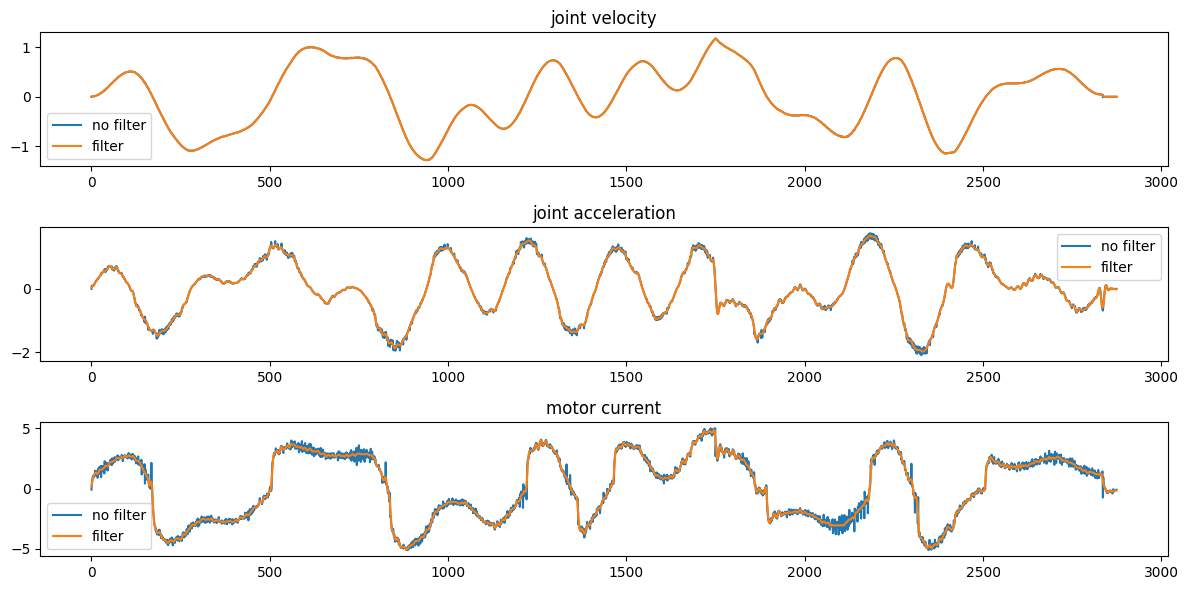

In [14]:
motor_drive_gains = np.array([14.87, 13.26, 11.13, 10.62, 11.03, 11.47])
traj = Trajectory()
# traj.num_points = data.shape[0]
traj.timestamp = data[:, 0]
traj.q = data[:, 1:7]
traj.qd = data[:, 7:13]
traj.motor_current = data[:, 13:19]

traj = data_process(traj, show=True)

# 力矩估计
traj.tau_est = traj.filtered_motor_current * motor_drive_gains

In [70]:
sol = optimize(robot, traj, base_qr_result, method="sdp")

(CVXPY) Aug 31 01:14:07 PM: Your problem has 84 variables, 126 constraints, and 0 parameters.
(CVXPY) Aug 31 01:14:07 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Aug 31 01:14:07 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Aug 31 01:14:07 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Aug 31 01:14:07 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Aug 31 01:14:07 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Aug 31 01:14:07 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Aug 31 01:14:07 PM: Applying reduction Dcp2Cone
(CVXPY) Aug 31 01:14:07 PM: Applying reduction CvxAttr2Constr
(CVXPY) Aug 31 01:14:07 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Aug 31 01:14:07 PM: Applying reduction CLARABEL
(CVXPY) Aug 31 01:14:07 PM: Finished problem compila

                                     CVXPY                                     
                                     v1.7.2                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 85
  constraints 

(CVXPY) Aug 31 01:14:08 PM: Problem status: optimal
(CVXPY) Aug 31 01:14:08 PM: Optimal value: 3.183e+02
(CVXPY) Aug 31 01:14:08 PM: Compilation took 1.518e-01 seconds
(CVXPY) Aug 31 01:14:08 PM: Solver (including time spent in interface) took 5.148e-01 seconds


 16  +3.1830e+02  +3.1830e+02  4.05e-10  1.69e-09  2.35e-11  1.78e-07  3.66e-07  9.47e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 490.552534ms
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
The optimal cost is 318.2991748254312


In [71]:
print(sol)

SolutionResult(est_std=array([0.01926268, 0.02184182, 0.02114675, 0.00484262, 0.03345232,
       0.0060054 , 0.18374335, 0.03334088, 0.04444697, 0.009659  ,
       0.01025162, 0.00732864, 0.03715246, 0.06634208, 0.18230187,
       0.00838978, 0.05048635, 0.18397808, 0.07250876, 0.00939742,
       0.00923721, 0.18933795, 0.07568608, 0.0741203 , 0.07584   ,
       0.0221024 , 0.05574656, 0.01353047, 0.12556335, 0.15377625,
       0.08008215, 0.0985    , 0.1578355 , 0.08961705, 0.08441434,
       0.08407826, 0.12512089, 0.15517178, 0.11238971, 0.18149673,
       0.15145779, 0.09354222, 0.04584159, 0.20437822, 0.0781391 ,
       0.16519625, 0.17618393, 0.07832967, 0.05635886, 0.19691564,
       0.07541986, 0.05924741, 0.17616845, 0.0782749 , 0.05263154,
       0.11807635, 0.08294433, 0.04816308]), est_rel_std=array([8.82263784e+02, 7.46265107e+02, 5.61120780e+02, 1.93761182e+01,
       2.43581112e+02, 3.09380111e+01, 2.29458548e+00, 7.39805517e+02,
       4.77892458e+01, 2.43711588e+01, 1.

In [30]:
cp.installed_solvers(
)

['CLARABEL', 'OSQP', 'SCIPY', 'SCS', 'SDPA']

In [50]:
x1 = cp.Variable(10)
x2 = cp.Variable(5)
cp.hstack([x1, x2])
A = cp.Variable((3, 10))
(A@x1).value